In [13]:
import os
import pandas as pd

In [14]:
methods_names = {
    "dist_linguistic_confidence": "Dist. Ling. Conf.",
    "dist_semantic_uncertainty": "Dist. Semantic Unc.",
    "dist_lnll": "Dist. Token Prob"
}

dataset_map = {
    "mmlu": "MMLU",
    "squadv2": "SQuADv2.0",
    "trivia_qa": "TriviaQA"
}

model_name_map = {
    "Llama-3.1-8B-Instruct": "Llama-3.1-8B-Inst.",
    "Meta-Llama-3-8B-Instruct": "Llama-3-8B-Inst.",
    "Qwen2.5-7B-Instruct": "Qwen2.5-7B-Inst.",
    "Qwen3-8B": "Qwen3-8B-Inst.",
    "Mistral-7B-Instruct-v0.3": "Mistral-7B-Inst.",
    "gpt-oss-20b": "GPT-OSS-20B",
}

In [15]:
calibration_mode = "univariate"

In [16]:
results_dir = f"/hdd/ivny/in_domain_{calibration_mode}_calibration"

# list all leaf nodes in results_dir
leaf_dirs = []
for root, dirs, files in os.walk(results_dir):
    if not dirs:  # if there are no subdirectories, it's a leaf node
        leaf_dirs.append(root)

all_records = []
for leaf_dir in leaf_dirs:
    _, _, _, _, dataset_name, estimation_method, _, model_name = leaf_dir.split("/")
    csv_data = pd.read_csv(os.path.join(leaf_dir, "linguistic_calibration_metrics.csv")).set_index("metric").transpose().to_dict(orient="records")[0]
    df_dict = {
        "Dataset": dataset_map[dataset_name],
        "Est. Method": methods_names[estimation_method],
        "Model": model_name_map[model_name],
        **csv_data
    }
    all_records.append(df_dict)

full_df = pd.DataFrame(all_records)

In [17]:
agg_mean_df = full_df.drop(columns=["Dataset"], errors="ignore").groupby(["Model", "Est. Method"]).mean()

In [18]:
"""
    {'original_linguistic_dECE': {('GPT-OSS-20B',
    'Dist. Ling. Conf.'): 0.2916254597674341,
    ('GPT-OSS-20B', 'Dist. Semantic Unc.'): 0.46022525994871977,
    ('GPT-OSS-20B', 'Dist. Token Prob'): 0.4386406846453226,
    ('Llama-3-8B-Inst.', 'Dist. Ling. Conf.'): 0.22225957479907202,
    ('Llama-3-8B-Inst.', 'Dist. Semantic Unc.'): 0.3684704524104137,
    ('Llama-3-8B-Inst.', 'Dist. Token Prob'): 0.3473601099655729,
    ('Llama-3.1-8B-Inst.', 'Dist. Ling. Conf.'): 0.16868553372037356,
    ('Llama-3.1-8B-Inst.', 'Dist. Semantic Unc.'): 0.3180531820073609,
    ('Llama-3.1-8B-Inst.', 'Dist. Token Prob'): 0.29913217513427304,
    ('Mistral-7B-Inst.', 'Dist. Ling. Conf.'): 0.29231398396568004,
    ('Mistral-7B-Inst.', 'Dist. Semantic Unc.'): 0.3542186148251772,
    ('Mistral-7B-Inst.', 'Dist. Token Prob'): 0.34839242787826796,
    ('Qwen2.5-7B-Inst.', 'Dist. Ling. Conf.'): 0.21126954370039774,
    ('Qwen2.5-7B-Inst.', 'Dist. Semantic Unc.'): 0.3652861052059204,
    ('Qwen2.5-7B-Inst.', 'Dist. Token Prob'): 0.36185634387130666,
    ('Qwen3-8B-Inst.', 'Dist. Ling. Conf.'): 0.2582913968489506,
    ('Qwen3-8B-Inst.', 'Dist. Semantic Unc.'): 0.401385672964146,
    ('Qwen3-8B-Inst.', 'Dist. Token Prob'): 0.37793099428817395},
    'original_linguistic_dAUROC': {('GPT-OSS-20B',
    'Dist. Ling. Conf.'): 0.5825955,
    ('GPT-OSS-20B', 'Dist. Semantic Unc.'): 0.5063083333333334,
    ('GPT-OSS-20B', 'Dist. Token Prob'): 0.5171016666666667,
    ('Llama-3-8B-Inst.', 'Dist. Ling. Conf.'): 0.5653011666666666,
    ('Llama-3-8B-Inst.', 'Dist. Semantic Unc.'): 0.5048911666666667,
    ('Llama-3-8B-Inst.', 'Dist. Token Prob'): 0.5160698333333333,
    ('Llama-3.1-8B-Inst.', 'Dist. Ling. Conf.'): 0.6446491666666666,
    ('Llama-3.1-8B-Inst.', 'Dist. Semantic Unc.'): 0.5767698333333334,
    ('Llama-3.1-8B-Inst.', 'Dist. Token Prob'): 0.5972974999999999,
    ('Mistral-7B-Inst.', 'Dist. Ling. Conf.'): 0.5483333333333333,
    ('Mistral-7B-Inst.', 'Dist. Semantic Unc.'): 0.5246203333333334,
    ('Mistral-7B-Inst.', 'Dist. Token Prob'): 0.5311246666666666,
    ('Qwen2.5-7B-Inst.', 'Dist. Ling. Conf.'): 0.5870369999999999,
    ('Qwen2.5-7B-Inst.', 'Dist. Semantic Unc.'): 0.5569698333333334,
    ('Qwen2.5-7B-Inst.', 'Dist. Token Prob'): 0.5566205000000001,
    ('Qwen3-8B-Inst.', 'Dist. Ling. Conf.'): 0.546975,
    ('Qwen3-8B-Inst.', 'Dist. Semantic Unc.'): 0.5248408333333333,
    ('Qwen3-8B-Inst.', 'Dist. Token Prob'): 0.5369405},
    'calibrated_linguistic_dECE': {('GPT-OSS-20B',
    'Dist. Ling. Conf.'): 0.1436220374224807,
    ('GPT-OSS-20B', 'Dist. Semantic Unc.'): 0.14887303782883152,
    ('GPT-OSS-20B', 'Dist. Token Prob'): 0.14517551508122284,
    ('Llama-3-8B-Inst.', 'Dist. Ling. Conf.'): 0.15075208951131278,
    ('Llama-3-8B-Inst.', 'Dist. Semantic Unc.'): 0.12651215726383877,
    ('Llama-3-8B-Inst.', 'Dist. Token Prob'): 0.11099527017542599,
    ('Llama-3.1-8B-Inst.', 'Dist. Ling. Conf.'): 0.12257217376875318,
    ('Llama-3.1-8B-Inst.', 'Dist. Semantic Unc.'): 0.1190488922150893,
    ('Llama-3.1-8B-Inst.', 'Dist. Token Prob'): 0.0985813855311747,
    ('Mistral-7B-Inst.', 'Dist. Ling. Conf.'): 0.15226331777177476,
    ('Mistral-7B-Inst.', 'Dist. Semantic Unc.'): 0.12596826849725531,
    ('Mistral-7B-Inst.', 'Dist. Token Prob'): 0.11766152288077773,
    ('Qwen2.5-7B-Inst.', 'Dist. Ling. Conf.'): 0.14584210013409873,
    ('Qwen2.5-7B-Inst.', 'Dist. Semantic Unc.'): 0.12170768353362156,
    ('Qwen2.5-7B-Inst.', 'Dist. Token Prob'): 0.10222561460920813,
    ('Qwen3-8B-Inst.', 'Dist. Ling. Conf.'): 0.14712248259224894,
    ('Qwen3-8B-Inst.', 'Dist. Semantic Unc.'): 0.12153869078924119,
    ('Qwen3-8B-Inst.', 'Dist. Token Prob'): 0.10248965789880837},
    'calibrated_linguistic_dAUROC': {('GPT-OSS-20B',
    'Dist. Ling. Conf.'): 0.5883723333333334,
    ('GPT-OSS-20B', 'Dist. Semantic Unc.'): 0.6028913333333333,
    ('GPT-OSS-20B', 'Dist. Token Prob'): 0.5577875,
    ('Llama-3-8B-Inst.', 'Dist. Ling. Conf.'): 0.5540280000000001,
    ('Llama-3-8B-Inst.', 'Dist. Semantic Unc.'): 0.5992660000000001,
    ('Llama-3-8B-Inst.', 'Dist. Token Prob'): 0.6692,
    ('Llama-3.1-8B-Inst.', 'Dist. Ling. Conf.'): 0.6353898333333333,
    ('Llama-3.1-8B-Inst.', 'Dist. Semantic Unc.'): 0.612489,
    ('Llama-3.1-8B-Inst.', 'Dist. Token Prob'): 0.7290416666666667,
    ('Mistral-7B-Inst.', 'Dist. Ling. Conf.'): 0.5471316666666667,
    ('Mistral-7B-Inst.', 'Dist. Semantic Unc.'): 0.5924913333333334,
    ('Mistral-7B-Inst.', 'Dist. Token Prob'): 0.6063873333333333,
    ('Qwen2.5-7B-Inst.', 'Dist. Ling. Conf.'): 0.5719146666666667,
    ('Qwen2.5-7B-Inst.', 'Dist. Semantic Unc.'): 0.6005919999999999,
    ('Qwen2.5-7B-Inst.', 'Dist. Token Prob'): 0.6328166666666667,
    ('Qwen3-8B-Inst.', 'Dist. Ling. Conf.'): 0.5427501666666666,
    ('Qwen3-8B-Inst.', 'Dist. Semantic Unc.'): 0.6068760000000001,
    ('Qwen3-8B-Inst.', 'Dist. Token Prob'): 0.649591}}
"""

agg_mean_df[["original_linguistic_dECE", "original_linguistic_dAUROC", "calibrated_linguistic_dECE", "calibrated_linguistic_dAUROC"]]

original_linguistic_dECE  \
Model              Est. Method                                     
GPT-OSS-20B        Dist. Ling. Conf.                    0.291625   
                   Dist. Semantic Unc.                  0.460225   
                   Dist. Token Prob                     0.438641   
Llama-3-8B-Inst.   Dist. Ling. Conf.                    0.222260   
                   Dist. Semantic Unc.                  0.368470   
                   Dist. Token Prob                     0.347360   
Llama-3.1-8B-Inst. Dist. Ling. Conf.                    0.168686   
                   Dist. Semantic Unc.                  0.318053   
                   Dist. Token Prob                     0.299132   
Mistral-7B-Inst.   Dist. Ling. Conf.                    0.292314   
                   Dist. Semantic Unc.                  0.354219   
                   Dist. Token Prob                     0.348392   
Qwen2.5-7B-Inst.   Dist. Ling. Conf.                    0.211270   
                   Dist. Semantic Unc.                  0.365286   
                   Dist. Token Prob                     0.361856   
Qwen3-8B-Inst.     Dist. Ling. Conf.                    0.258291   
                   Dist. Semantic Unc.                  0.401386   
                   Dist. Token Prob                     0.377931   

                                        original_linguistic_dAUROC  \
Model              Est. Method                                       
GPT-OSS-20B        Dist. Ling. Conf.                      0.582596   
                   Dist. Semantic Unc.                    0.506308   
                   Dist. Token Prob                       0.517102   
Llama-3-8B-Inst.   Dist. Ling. Conf.                      0.565301   
                   Dist. Semantic Unc.                    0.504891   
                   Dist. Token Prob                       0.516070   
Llama-3.1-8B-Inst. Dist. Ling. Conf.                      0.644649   
                   Dist. Semantic Unc.                    0.576770   
                   Dist. Token Prob                       0.597297   
Mistral-7B-Inst.   Dist. Ling. Conf.                      0.548333   
                   Dist. Semantic Unc.                    0.524620   
                   Dist. Token Prob                       0.531125   
Qwen2.5-7B-Inst.   Dist. Ling. Conf.                      0.587037   
                   Dist. Semantic Unc.                    0.556970   
                   Dist. Token Prob                       0.556621   
Qwen3-8B-Inst.     Dist. Ling. Conf.                      0.546975   
                   Dist. Semantic Unc.                    0.524841   
                   Dist. Token Prob                       0.536941   

                                        calibrated_linguistic_dECE  \
Model              Est. Method                                       
GPT-OSS-20B        Dist. Ling. Conf.                      0.143622   
                   Dist. Semantic Unc.                    0.148873   
                   Dist. Token Prob                       0.145176   
Llama-3-8B-Inst.   Dist. Ling. Conf.                      0.150752   
                   Dist. Semantic Unc.                    0.126512   
                   Dist. Token Prob                       0.110995   
Llama-3.1-8B-Inst. Dist. Ling. Conf.                      0.122572   
                   Dist. Semantic Unc.                    0.119049   
                   Dist. Token Prob                       0.098581   
Mistral-7B-Inst.   Dist. Ling. Conf.                      0.152263   
                   Dist. Semantic Unc.                    0.125968   
                   Dist. Token Prob                       0.117662   
Qwen2.5-7B-Inst.   Dist. Ling. Conf.                      0.145842   
                   Dist. Semantic Unc.                    0.121708   
                   Dist. Token Prob                       0.102226   
Qwen3-8B-Inst.     Dist. Ling. Conf.                      0.147122   
                  

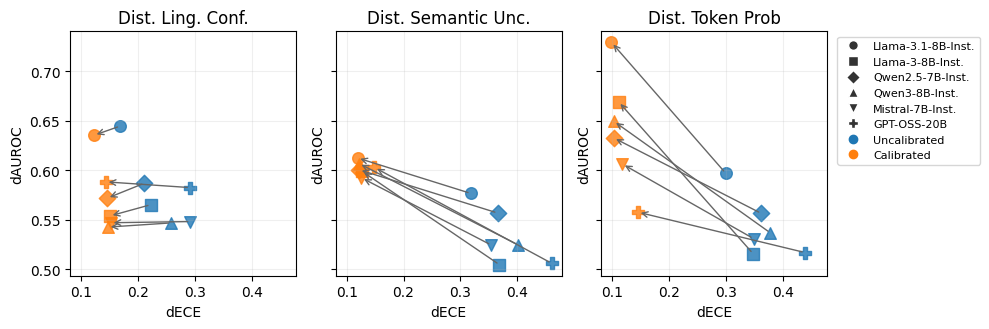

In [19]:
import matplotlib.pyplot as plt

plot_df = agg_mean_df.reset_index()

metrics = {
    "original": ("original_linguistic_dECE", "original_linguistic_dAUROC"),
    "calibrated": ("calibrated_linguistic_dECE", "calibrated_linguistic_dAUROC"),
}

method_order = [methods_names[key] for key in methods_names]
model_order = [model_name_map[key] for key in model_name_map]

marker_map = {
    "Llama-3.1-8B-Inst.": "o",
    "Llama-3-8B-Inst.": "s",
    "Qwen2.5-7B-Inst.": "D",
    "Qwen3-8B-Inst.": "^",
    "Mistral-7B-Inst.": "v",
    "GPT-OSS-20B": "P",
}

fig, axes = plt.subplots(1, 3, figsize=(10, 3.4), sharex=True, sharey=True)
for ax, method in zip(axes, method_order):
    df_method = plot_df[plot_df["Est. Method"] == method]
    for model in model_order:
        row = df_method[df_method["Model"] == model]
        if row.empty:
            continue
        row = row.iloc[0]
        x0, y0 = row[metrics["original"][0]], row[metrics["original"][1]]
        x1, y1 = row[metrics["calibrated"][0]], row[metrics["calibrated"][1]]
        marker = marker_map.get(model, "o")
        ax.scatter(x0, y0, marker=marker, s=70, color="tab:blue", alpha=0.8)
        ax.scatter(x1, y1, marker=marker, s=70, color="tab:orange", alpha=0.8)
        ax.annotate(
            "",
            xy=(x1, y1),
            xytext=(x0, y0),
            arrowprops=dict(arrowstyle="->", color="0.4", lw=1),
        )
    ax.set_title(method)
    ax.set_xlabel("dECE")
    ax.set_ylabel("dAUROC")
    ax.grid(True, alpha=0.2)

model_handles = [
    plt.Line2D([0], [0], marker=marker_map[m], color="w", label=m,
               markerfacecolor="0.2", markersize=7)
    for m in model_order
    if m in marker_map
]
status_handles = [
    plt.Line2D([0], [0], marker="o", color="tab:blue", label="Uncalibrated",
               markerfacecolor="tab:blue", markersize=6, linestyle="None"),
    plt.Line2D([0], [0], marker="o", color="tab:orange", label="Calibrated",
               markerfacecolor="tab:orange", markersize=6, linestyle="None"),
]

axes[-1].legend(
    handles=model_handles + status_handles,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True,
    fontsize=8,
)
# fig.suptitle("Post-Hoc Linguistic Calibration (In-Domain)", y=1.02)
plt.tight_layout()
plt.savefig(f"{calibration_mode}_post_hoc_linguistic_calibration_in_domain.pdf", bbox_inches='tight', dpi=300)